In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [44]:
df_netflix = pd.read_csv(r"C:\Users\HRICHEEK\Downloads\netflix.csv")

In [45]:
df_netflix.shape

(8807, 12)

In [46]:
print("THe Shape of Data:", df_netflix.shape)

THe Shape of Data: (8807, 12)


In [47]:
print("\nThe Dataset information:", df_netflix.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

The Dataset information: None


In [48]:
## Check Nul Values

df_netflix.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [49]:
df_netflix.duplicated().sum()

np.int64(0)

In [50]:
df_netflix.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [51]:
total_null_values = df_netflix.isnull().sum().sum()
print(f"Total null values in Netflix Dataset: {total_null_values}")

Total null values in Netflix Dataset: 4307


In [52]:
df_netflix.notnull().sum()

show_id         8807
type            8807
title           8807
director        6173
cast            7982
country         7976
date_added      8797
release_year    8807
rating          8803
duration        8804
listed_in       8807
description     8807
dtype: int64

In [53]:
## Count Missing Values per Column

missing = df_netflix.isnull().sum()
print("Missing Values:\n", missing[missing>0])

Missing Values:
 director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64


In [54]:
# Percentage of Missing Values

missing_percentage = (df_netflix.isnull().sum() / len(df_netflix)) * 100
print("Missing Data Percentage:\n", missing_percentage[missing_percentage>0])

Missing Data Percentage:
 director      29.908028
cast           9.367549
country        9.435676
date_added     0.113546
rating         0.045418
duration       0.034064
dtype: float64


In [55]:
## Filling missing categorical values with 'Unknown'

df_netflix.director.fillna('Unknown', inplace=True)
df_netflix.cast.fillna('Unknown', inplace=True)
df_netflix.country.fillna('Unknown', inplace=True)
df_netflix.rating.fillna('Unknown', inplace=True)
df_netflix.duration.fillna('Unknown', inplace=True)

C:\Users\HRICHEEK\AppData\Local\Temp\ipykernel_21740\1475598594.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_netflix.director.fillna('Unknown', inplace=True)
C:\Users\HRICHEEK\AppData\Local\Temp\ipykernel_21740\1475598594.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

In [56]:
missing = df_netflix.isnull().sum()
print("Missing Values:\n", missing[missing>0])

Missing Values:
 date_added    10
dtype: int64


In [57]:
df_netflix.date_added.value_counts()

date_added
January 1, 2020      109
November 1, 2019      89
March 1, 2018         75
December 31, 2019     74
October 1, 2018       71
                    ... 
June 15, 2014          1
November 18, 2017      1
February 8, 2016       1
October 21, 2018       1
 June 1, 2018          1
Name: count, Length: 1767, dtype: int64

In [58]:
##Drop rows with missing date added

df_netflix.dropna(subset=['date_added'],inplace=True)

print("Missing data after cleaning:\n", df_netflix.isnull().sum())

Missing data after cleaning:
 show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [59]:
# Convert datatypes

df_netflix.date_added= pd.to_datetime(df_netflix.date_added, format = "%B, %d, %Y", errors = 'coerce')

df_netflix.release_year = df_netflix.release_year.astype(int)

df_netflix.info()


<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   object        
 1   type          8797 non-null   object        
 2   title         8797 non-null   object        
 3   director      8797 non-null   object        
 4   cast          8797 non-null   object        
 5   country       8797 non-null   object        
 6   date_added    0 non-null      datetime64[ns]
 7   release_year  8797 non-null   int64         
 8   rating        8797 non-null   object        
 9   duration      8797 non-null   object        
 10  listed_in     8797 non-null   object        
 11  description   8797 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 893.4+ KB


In [60]:
df_netflix.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [61]:
df_netflix.listed_in

0                                           Documentaries
1         International TV Shows, TV Dramas, TV Mysteries
2       Crime TV Shows, International TV Shows, TV Act...
3                                  Docuseries, Reality TV
4       International TV Shows, Romantic TV Shows, TV ...
                              ...                        
8802                       Cult Movies, Dramas, Thrillers
8803               Kids' TV, Korean TV Shows, TV Comedies
8804                              Comedies, Horror Movies
8805                   Children & Family Movies, Comedies
8806       Dramas, International Movies, Music & Musicals
Name: listed_in, Length: 8797, dtype: object

In [62]:
df_netflix['genres'] = df_netflix['listed_in'].str.split(', ')

In [63]:
df_netflix.genres

0                                         [Documentaries]
1       [International TV Shows, TV Dramas, TV Mysteries]
2       [Crime TV Shows, International TV Shows, TV Ac...
3                                [Docuseries, Reality TV]
4       [International TV Shows, Romantic TV Shows, TV...
                              ...                        
8802                     [Cult Movies, Dramas, Thrillers]
8803             [Kids' TV, Korean TV Shows, TV Comedies]
8804                            [Comedies, Horror Movies]
8805                 [Children & Family Movies, Comedies]
8806     [Dramas, International Movies, Music & Musicals]
Name: genres, Length: 8797, dtype: object

In [64]:
df_netflix['primary_country'] = df_netflix['country'].str.split(',').str[0]

In [65]:
df_netflix.primary_country

0       United States
1        South Africa
2             Unknown
3             Unknown
4               India
            ...      
8802    United States
8803          Unknown
8804    United States
8805    United States
8806            India
Name: primary_country, Length: 8797, dtype: object

In [66]:
df_netflix['duration_numeric'] = df_netflix['duration'].str.extract('(\d+)', expand=False).astype(float)
df_netflix['unit'] = df_netflix['duration'].str.extract('([a-zA-Z]+)', expand = False)

In [67]:
df_netflix.duration_numeric

0        90.0
1         2.0
2         1.0
3         1.0
4         2.0
        ...  
8802    158.0
8803      2.0
8804     88.0
8805     88.0
8806    111.0
Name: duration_numeric, Length: 8797, dtype: float64

In [68]:
# Viewing the Changes

df_netflix[['listed_in', 'genres', 'country', 'primary_country', 'duration_numeric', 'unit']].head()

,listed_in,genres,country,primary_country,duration_numeric,unit
0,Documentaries,[Documentaries],United States,United States,90.0,min
1,"International TV Shows, TV Dramas, TV Mysteries","[International TV Shows, TV Dramas, TV Mysteries]",South Africa,South Africa,2.0,Seasons
2,"Crime TV Shows, International TV Shows, TV Act...","[Crime TV Shows, International TV Shows, TV Ac...",Unknown,Unknown,1.0,Season
3,"Docuseries, Reality TV","[Docuseries, Reality TV]",Unknown,Unknown,1.0,Season
4,"International TV Shows, Romantic TV Shows, TV ...","[International TV Shows, Romantic TV Shows, TV...",India,India,2.0,Seasons


In [69]:
# Remomoving Duplicates

df_netflix.drop_duplicates(subset=['title','type'], inplace = True)

df_netflix.shape


(8797, 16)

In [70]:
# Types Summary

print(df_netflix.type.value_counts())

type
Movie      6131
TV Show    2666
Name: count, dtype: int64


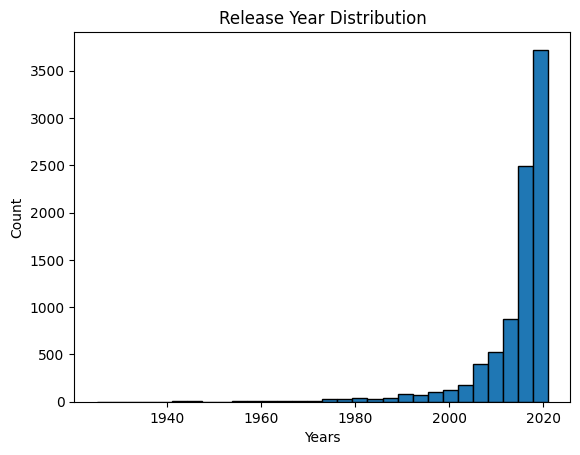

In [71]:
## Plotting release years

df_netflix.release_year.hist(bins = 30, edgecolor = 'k')
plt.title("Release Year Distribution")
plt.xlabel('Years')
plt.ylabel('Count')
plt.grid(False)
plt.show()


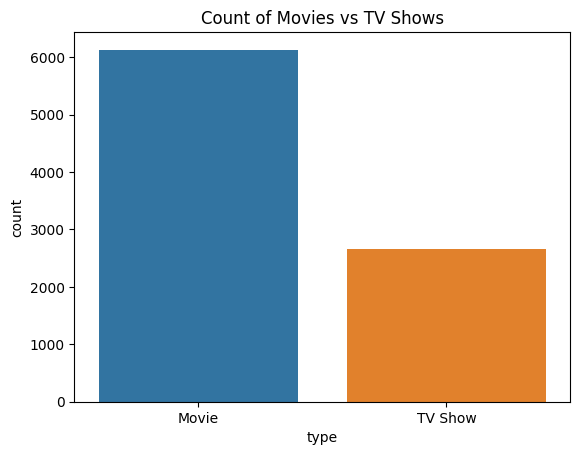

In [72]:
# Display Movies vs TV Shows

sns.countplot(data = df_netflix, x = 'type', hue= 'type')
plt.title("Count of Movies vs TV Shows")
plt.show()

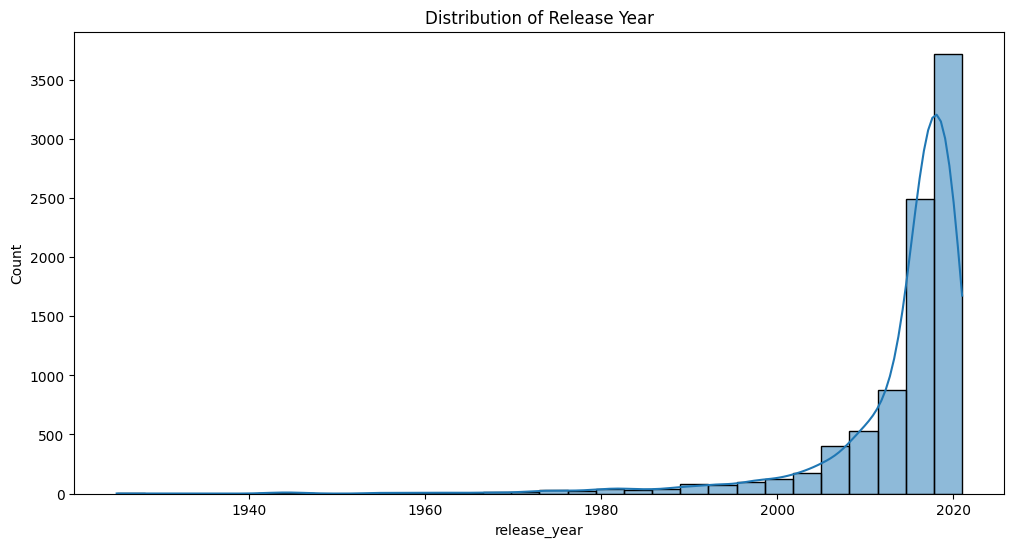

In [73]:
# Distribution of Release Year

plt.figure(figsize=(12,6))
sns.histplot(data = df_netflix, x= 'release_year', bins = 30, kde = True)
plt.title("Distribution of Release Year")
plt.show()

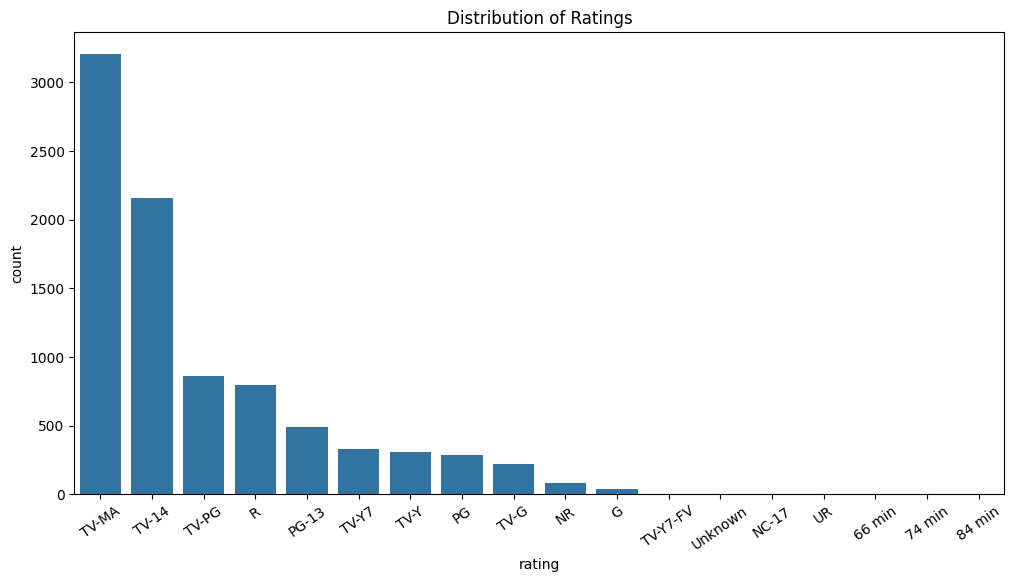

In [74]:
## Rating Distribution

plt.figure(figsize=(12,6))
sns.countplot(data = df_netflix, x = 'rating', order = df_netflix.rating.value_counts().index)
plt.xticks(rotation=35)
plt.title('Distribution of Ratings')
plt.show()


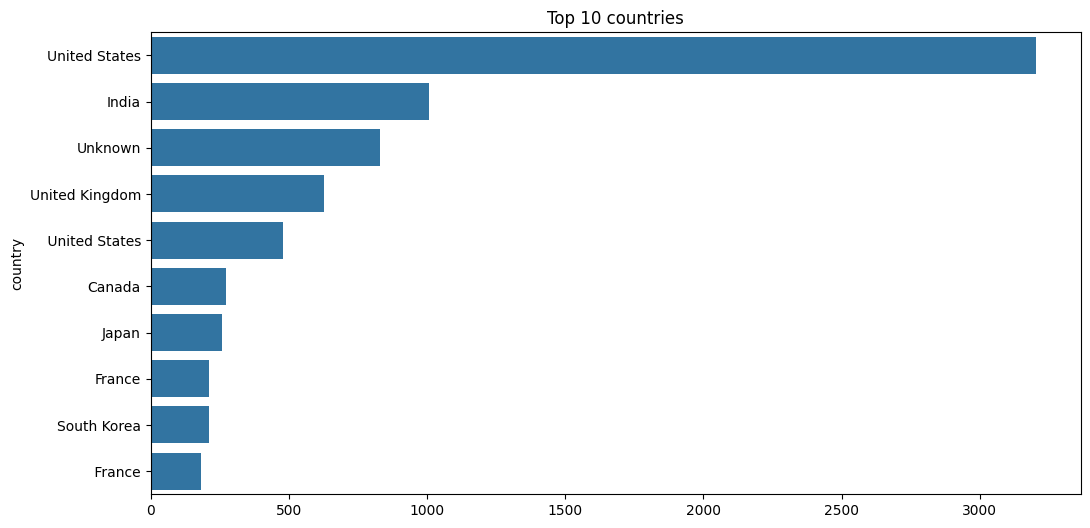

In [80]:
# Top 10 countries

country_counts = df_netflix.country.dropna().str.split(",").explode().value_counts().nlargest(10)
plt.figure(figsize=(12,6))
sns.barplot(x= country_counts.values, y = country_counts.index)
plt.title('Top 10 countries')
plt.show()

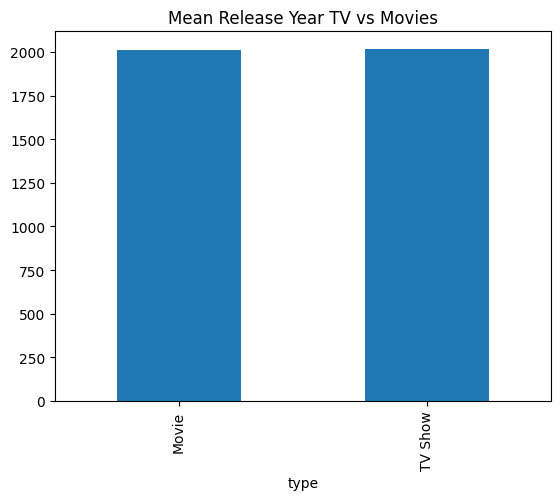

In [83]:
# Mean of release year by type

df_netflix.groupby('type')['release_year'].mean().plot(kind='bar')
plt.title("Mean Release Year TV vs Movies")
plt.show()